<a href="https://colab.research.google.com/github/smuziVpyze/russian-market-news-analysis/blob/main/01_data_loading.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. СБОР И ЗАГРУЗКА ДАННЫХ

Первый этап работы посвящён сбору и первичной обработке данных. Нам необходимо было собрать достаточный объём финансовых новостей и рыночных котировок, чтобы в дальнейшем исследовать связь между новостным фоном и динамикой российского фондового рынка.

In [1]:
# Установка необходимых библиотек
!pip install kaggle apimoex requests pandas pyarrow fastparquet -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 24.6 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Создаем структура проекта на Google Drive

In [3]:
import os

# Корневая папка проекта на Google Drive
PROJECT_DIR = '/content/drive/MyDrive/russian_market_news_analysis'

# Создаём структуру
folders = [
    'data/raw/news',
    'data/raw/market',
    'data/processed',
    'data/features',
    'models',
    'reports/figures',
]

for folder in folders:
    os.makedirs(f'{PROJECT_DIR}/{folder}', exist_ok=True)


for folder in folders:
    print(f'✓ {PROJECT_DIR}/{folder}')

✓ /content/drive/MyDrive/russian_market_news_analysis/data/raw/news
✓ /content/drive/MyDrive/russian_market_news_analysis/data/raw/market
✓ /content/drive/MyDrive/russian_market_news_analysis/data/processed
✓ /content/drive/MyDrive/russian_market_news_analysis/data/features
✓ /content/drive/MyDrive/russian_market_news_analysis/models
✓ /content/drive/MyDrive/russian_market_news_analysis/reports/figures


В качестве основного источника новостных данных был использован датасет RussianFinancialNews с платформы Kaggle (автор: Kasymkhan K., лицензия Apache 2.0). Датасет содержит 91,955 русскоязычных финансовых новостей, опубликованных на следующих платформах:
* Finam — финансовый портал
* RBC — федеральное деловое издание
* BCS Express — аналитический ресурс брокера БКС
* RDV — Telegram-канал для инвесторов
* T-Invest — Telegram-канал Т-Банка
* SmartLab — сообщество трейдеров





Каждая запись содержит следующие поля: заголовок (title), текст статьи (body), дата публикации (date), время (time), ключевые слова (tags), источник (source).

Котировки были получены из двух источников:
* Датасет RussianFinancialNews — содержит дневные свечи 176 компаний MOEX с июля 2022 по август 2024
* MOEX ISS API — для дозагрузки данных по тикерам после редомициляции (YNDX→YDEX, FIVE→X5)



Скачиваем датасет прямо в папку на Drive

In [4]:
import os


KAGGLE_TOKEN = 'KGAT_16a86f3fc3bdd07fc81a0ec06c572e6f'

os.environ['KAGGLE_TOKEN'] = KAGGLE_TOKEN

!kaggle datasets download -d kkhubiev/russian-financial-news \
    -p '{PROJECT_DIR}/data/raw/news' \
    --unzip

print('Датасет скачан')

Dataset URL: https://www.kaggle.com/datasets/kkhubiev/russian-financial-news
License(s): apache-2.0
100% 184M/184M [00:03<00:00, 56.2MB/s]

User cancelled operation
Датасет скачан


Смотрим что скачалось

In [6]:
import os


news_dir = f'{PROJECT_DIR}/data/raw/news'

for root, dirs, files in os.walk(news_dir):
    level = root.replace(news_dir, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    for file in files:
        filepath = os.path.join(root, file)
        size = os.path.getsize(filepath) / (1024*1024)
        print(f'{indent}  {file} ({size:.1f} MB)')

news/
  news_clean.csv (112.5 MB)
  russian-financial-news.zip (184.0 MB)
  RussianFinancialNews/
    news_collection.parquet (35.8 MB)
    preview.csv (0.0 MB)
    tickers_description.json (0.9 MB)
    candles_data/
      10m/
        close.csv (42.9 MB)
        high.csv (42.8 MB)
        low.csv (42.8 MB)
        open.csv (42.9 MB)
        value.csv (68.3 MB)
      1d/
        close.csv (0.7 MB)
        high.csv (0.7 MB)
        low.csv (0.7 MB)
        open.csv (0.7 MB)
        value.csv (1.2 MB)
        volume.csv (0.8 MB)
      1h/
        close.csv (8.4 MB)
        high.csv (8.4 MB)
        low.csv (8.4 MB)
        open.csv (8.4 MB)
        value.csv (14.1 MB)
        volume.csv (8.0 MB)
    news_descriptions/
      news_collection_old.parquet (47.4 MB)
      news_description_LLama3_8b.json (0.0 MB)
      news_descriptions_GPT4o.json (9.0 MB)


## Новости

Загружаем новости

In [8]:
import pandas as pd


news_path = f'{PROJECT_DIR}/data/raw/news/RussianFinancialNews/news_collection.parquet'
df_news = pd.read_parquet(news_path)

print(f'Размер датасета: {df_news.shape}')
print(f'\nКолонки: {df_news.columns.tolist()}')
print(f'\nТипы данных:\n{df_news.dtypes}')
print(f'\nПервые 3 строки:')
df_news.head(3)

Размер датасета: (91955, 6)

Колонки: ['title', 'body', 'date', 'time', 'tags', 'source']

Типы данных:
title     object
body      object
date      object
time      object
tags      object
source    object
dtype: object

Первые 3 строки:


,title,body,date,time,tags,source
0,no title,"""После падения добычи в 2022-2023 годах Газпро...",2024-09-09,16:16:54,['цифры'],rdv
1,no title,""" Рейтинг акций комьюнити РДВ. #опрос """,2024-09-09,15:38:21,['опрос'],rdv
2,no title,"""Нефть Brent упала до $71, Urals - до $60 за б...",2024-09-09,14:40:17,['шокновости'],rdv


In [9]:
print('--- Период ---')
df_news['date'] = pd.to_datetime(df_news['date'], format='mixed').dt.date
df_news['date'] = pd.to_datetime(df_news['date'])
print(f'С: {df_news["date"].min()}')
print(f'По: {df_news["date"].max()}')

print('\n--- Источники ---')
print(df_news['source'].value_counts())

print('\n--- Пропуски ---')
print(df_news.isnull().sum())

print('\n--- Пустые заголовки ---')
no_title = (df_news['title'] == 'no title').sum()
print(f'Новостей без заголовка: {no_title} ({no_title/len(df_news)*100:.1f}%)')

--- Период ---
С: 2009-06-19 00:00:00
По: 2024-12-16 00:00:00

--- Источники ---
source
smart_lab     34517
finam         22433
bcs           12424
bcs_tech      11560
rdv            5721
t_invest       4498
t_analytic      802
Name: count, dtype: int64

--- Пропуски ---
title     0
body      0
date      0
time      0
tags      0
source    0
dtype: int64

--- Пустые заголовки ---
Новостей без заголовка: 45538 (49.5%)


После загрузки датасета была проведена первичная фильтрация:
* Ограничение периода: 2022-07-01 — 2024-08-30 (пересечение с доступными рыночными данными)
* Минимальная длина текста: 50 символов (исключение слишком коротких и нерелевантных записей)
* Для статей без заголовка (no title) использовался только текст body
* Был сформирован единый текстовый признак full_text = заголовок + текст


In [10]:
print('--- Фильтрация ---')

# Оставляем только нужный период 2022-2024
df_filtered = df_news[df_news['date'] >= '2022-01-01'].copy()
print(f'После фильтра по дате (2022+): {len(df_filtered)}')

# Смотрим источники после фильтра
print('\nИсточники после фильтра:')
print(df_filtered['source'].value_counts())

# Смотрим no title по источникам
print('\nNo title по источникам:')
no_title_by_source = df_filtered[df_filtered['title'] == 'no title']['source'].value_counts()
print(no_title_by_source)

# Длина текста
df_filtered['text_len'] = df_filtered['body'].str.len()
print(f'\nДлина текста (символов):')
print(df_filtered['text_len'].describe().round(0))

--- Фильтрация ---
После фильтра по дате (2022+): 82169

Источники после фильтра:
source
smart_lab     34517
finam         22433
bcs            8882
rdv            5721
bcs_tech       5316
t_invest       4498
t_analytic      802
Name: count, dtype: int64

No title по источникам:
source
smart_lab     34517
rdv            5721
t_invest       4498
t_analytic      802
Name: count, dtype: int64

Длина текста (символов):
count    82169.0
mean       367.0
std        827.0
min          7.0
25%         68.0
50%         95.0
75%        154.0
max       5178.0
Name: text_len, dtype: float64


In [11]:
# Оставляем всё у чего есть нормальный текст
df_clean = df_filtered[
    df_filtered['text_len'] >= 50  # минимум 50 символов
].copy()

# Для анализа будем использовать: если есть заголовок — title + body, иначе только body
df_clean['full_text'] = df_clean.apply(
    lambda row: row['title'] + '. ' + row['body']
    if row['title'] != 'no title'
    else row['body'],
    axis=1
)

print(f'Итого новостей: {len(df_clean)}')
print(f'\nПо источникам:')
print(df_clean['source'].value_counts())
print(f'\nПериод: {df_clean["date"].min()} → {df_clean["date"].max()}')
print(f'\nДлина full_text (символов):')
print(df_clean['full_text'].str.len().describe().round(0))

Итого новостей: 74155

По источникам:
source
smart_lab     32131
finam         18209
bcs            7627
rdv            5576
bcs_tech       5316
t_invest       4495
t_analytic      801
Name: count, dtype: int64

Период: 2022-01-02 00:00:00 → 2024-12-16 00:00:00

Длина full_text (символов):
count    74155.0
mean       430.0
std        862.0
min         50.0
25%         94.0
50%        140.0
75%        212.0
max       5227.0
Name: full_text, dtype: float64


После фильтрации в датасете осталось 74,155 новостей из 91,955 исходных.

## Котировки

Котировки были получены из двух источников:
* Датасет RussianFinancialNews — содержит дневные свечи 176 компаний MOEX с июля 2022 по август 2024
* MOEX ISS API — для дозагрузки данных по тикерам после редомициляции (YNDX→YDEX, FIVE→X5)


In [12]:
import os

# Загружаем дневные котировки
candles_dir = f'{PROJECT_DIR}/data/raw/news/RussianFinancialNews/candles_data/1d'

df_close = pd.read_csv(f'{candles_dir}/close.csv', index_col=0)

print(f'Размер: {df_close.shape}')
print(f'\nПервые колонки (тикеры):')
print(df_close.columns[:20].tolist())
print(f'\nПериод (индекс):')
print(f'С: {df_close.index[0]}')
print(f'По: {df_close.index[-1]}')
print(f'\nПервые строки:')
df_close.head(3)

Размер: (553, 252)

Первые колонки (тикеры):
['ABIO', 'ABRD', 'ACKO', 'AFKS', 'AFLT', 'AGRO', 'AKRN', 'ALRS', 'AMEZ', 'APRI', 'APTK', 'AQUA', 'ARSA', 'ASSB', 'ASTR', 'AVAN', 'BANE', 'BANEP', 'BELU', 'BISVP']

Период (индекс):
С: 2022-07-01
По: 2024-08-30

Первые строки:


,ABIO,ABRD,ACKO,AFKS,AFLT,AGRO,AKRN,ALRS,AMEZ,APRI,...,WUSH,YAKG,YDEX,YKEN,YKENP,YRSB,YRSBP,ZAYM,ZILL,ZVEZ
begin,,,,,,,,,,,,,,,,,,,,,
2022-07-01,56.28,171.5,NaN,14.85,26.74,872.0,18660,66.24,21.220,NaN,...,NaN,107.0,NaN,0.282,0.2785,170.0,82.5,NaN,2920,3.50
2022-07-04,56.90,173.0,NaN,15.00,27.12,854.4,18422,64.55,21.895,NaN,...,NaN,109.5,NaN,0.283,0.2785,172.0,83.0,NaN,3010,3.48
2022-07-05,56.38,172.5,NaN,15.00,28.26,837.2,17902,64.99,21.500,NaN,...,NaN,109.2,NaN,0.273,0.2680,170.0,82.5,NaN,2950,3.47


In [13]:
# Наши тикеры
OUR_TICKERS = ['SBER', 'GAZP', 'LKOH', 'YDEX', 'PLZL', 'FIVE']

print('--- Наличие тикеров ---')
for ticker in OUR_TICKERS:
    if ticker in df_close.columns:
        data = df_close[ticker].dropna()
        print(f'{ticker}: {len(data)} дней, с {data.index[0]} по {data.index[-1]}')
    else:
        print(f'{ticker}: не найден')

print(f'\nВсего тикеров в датасете: {len(df_close.columns)}')

--- Наличие тикеров ---
SBER: 553 дней, с 2022-07-01 по 2024-08-30
GAZP: 553 дней, с 2022-07-01 по 2024-08-30
LKOH: 553 дней, с 2022-07-01 по 2024-08-30
YDEX: 28 дней, с 2024-07-24 по 2024-08-30
PLZL: 553 дней, с 2022-07-01 по 2024-08-30
FIVE: 448 дней, с 2022-07-01 по 2024-04-03

Всего тикеров в датасете: 252


Можно увидеть, что у интересующих нас тикеров YDEX и FIVE недостаточно тогровых дней. Связано это с редомициляцией компаний.


Сохраним сначала тикеры по которым есть все торговые дни

In [14]:
# Загружаем все файлы котировок
df_open   = pd.read_csv(f'{candles_dir}/open.csv',   index_col=0)
df_high   = pd.read_csv(f'{candles_dir}/high.csv',   index_col=0)
df_low    = pd.read_csv(f'{candles_dir}/low.csv',    index_col=0)
df_volume = pd.read_csv(f'{candles_dir}/volume.csv', index_col=0)

# Только тикеры с полными данными
TICKERS = ['SBER', 'GAZP', 'LKOH', 'PLZL']

# Собираем в один DataFrame для каждого тикера
market_data = {}

for ticker in TICKERS:
    df_ticker = pd.DataFrame({
        'open':   df_open[ticker],
        'high':   df_high[ticker],
        'low':    df_low[ticker],
        'close':  df_close[ticker],
        'volume': df_volume[ticker],
    })
    df_ticker.index = pd.to_datetime(df_ticker.index)
    df_ticker = df_ticker.dropna()
    market_data[ticker] = df_ticker
    print(f'{ticker}: {len(df_ticker)} дней, {df_ticker.index[0].date()} → {df_ticker.index[-1].date()}')

print(f'\nИтого тикеров: {len(market_data)}')

SBER: 553 дней, 2022-07-01 → 2024-08-30
GAZP: 553 дней, 2022-07-01 → 2024-08-30
LKOH: 553 дней, 2022-07-01 → 2024-08-30
PLZL: 553 дней, 2022-07-01 → 2024-08-30

Итого тикеров: 4


Найдем среди тикеров индекс Мосбиржи, который показывает общее направление движения цен акций крупнейших и наиболее ликвидных российских компаний на Московской бирже и сохраним его

In [15]:
# Ищем индекс MOEX
imoex_cols = [col for col in df_close.columns if 'IMOEX' in col or 'MOEX' in col or 'MX' in col]
print('Индексы в датасете:', imoex_cols)

Индексы в датасете: ['MOEX']


In [16]:
# Добавляем индекс MOEX
df_moex = pd.DataFrame({
    'open':   df_open['MOEX'],
    'high':   df_high['MOEX'],
    'low':    df_low['MOEX'],
    'close':  df_close['MOEX'],
    'volume': df_volume['MOEX'],
})
df_moex.index = pd.to_datetime(df_moex.index)
df_moex = df_moex.dropna()
market_data['MOEX'] = df_moex

print(f'MOEX: {len(df_moex)} дней, {df_moex.index[0].date()} → {df_moex.index[-1].date()}')
print(f'\nИтого инструментов: {len(market_data)}')

MOEX: 553 дней, 2022-07-01 → 2024-08-30

Итого инструментов: 5


Используем MOEX ISS APU для дозагрузки данных по тикерам Яндекса и X5

После редомициляции тикеры изменились

YNDX→YDEX, FIVE→X5

In [19]:
!pip install apimoex -q

import requests
import apimoex

def fetch_moex_ticker(ticker, date_start, date_end, market='shares'):
    """Загрузить дневные свечи с MOEX ISS API."""
    with requests.Session() as session:
        data = apimoex.get_market_candles(
            session=session,
            security=ticker,
            interval=24,
            start=date_start,
            end=date_end,
            market=market,
            engine='stock',
        )
    if not data:
        print(f'Нет данных для {ticker}')
        return None

    df = pd.DataFrame(data)
    cols = [c for c in ['begin', 'open', 'high', 'low', 'close', 'volume'] if c in df.columns]
    df = df[cols].rename(columns={'begin': 'date'})
    df['date'] = pd.to_datetime(df['date'])
    df = df.set_index('date').sort_index()
    print(f'{ticker}: {len(df)} дней, {df.index[0].date()} → {df.index[-1].date()}')
    return df

DATE_START = '2022-07-01'
DATE_END   = '2024-08-30'

print('--- ЯНДЕКС ---')
df_yndx = fetch_moex_ticker('YNDX', DATE_START, DATE_END)
df_ydex = fetch_moex_ticker('YDEX', DATE_START, DATE_END)

print('\n--- X5 ---')
df_five = fetch_moex_ticker('FIVE', DATE_START, DATE_END)
df_x5   = fetch_moex_ticker('X5',   DATE_START, DATE_END)

--- ЯНДЕКС ---
YNDX: 498 дней, 2022-07-01 → 2024-06-14
YDEX: 28 дней, 2024-07-24 → 2024-08-30

--- X5 ---
FIVE: 448 дней, 2022-07-01 → 2024-04-03
Нет данных для X5


Итоговый список инструментов для анализа:

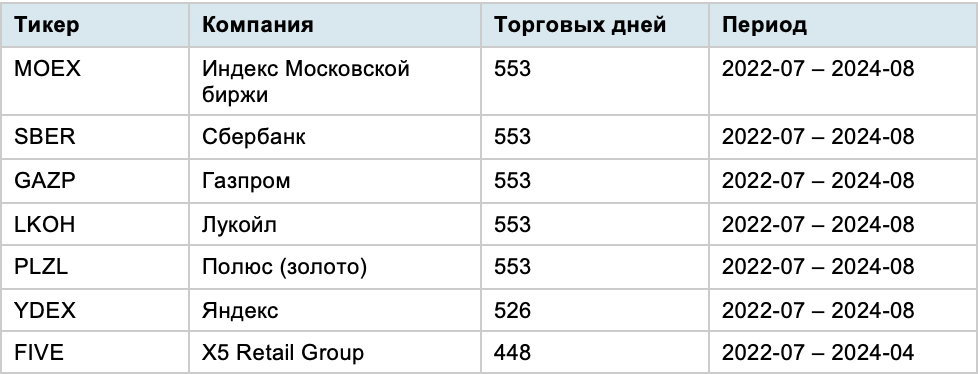

## Сохраняем собранные данные

In [20]:
market_dir = f'{PROJECT_DIR}/data/raw/market'

# Сохраняем
for ticker in ['YDEX', 'X5']:
    path = f'{market_dir}/{ticker}.csv'
    market_data[ticker].to_csv(path)
    print(f'Сохранён: {ticker}.csv')

print(f'\n--- Итого инструментов: {len(market_data)} ---')
for ticker, df in market_data.items():
    print(f'  {ticker}: {len(df)} дней, {df.index[0].date()} → {df.index[-1].date()}')

KeyError: 'YDEX'

In [21]:
# Сохраняем очищенные новости
news_path_clean = f'{PROJECT_DIR}/data/raw/news/news_clean.csv'
df_clean.to_csv(news_path_clean, index=False)
print(f'Сохранены новости: news_clean.csv ({len(df_clean):,} строк)')

print('\n--- Итог ноутбука 01 ---')
print(f'Новостей:        {len(df_clean):,}')
print(f'Источники:       {df_clean["source"].unique().tolist()}')
print(f'Период новостей: {df_clean["date"].min().date()} → {df_clean["date"].max().date()}')
print(f'\nРыночные данные:')
for ticker, df in market_data.items():
    print(f'  {ticker}: {len(df)} дней, {df.index[0].date()} → {df.index[-1].date()}')
print(f'\nПересечение периодов:')
print(f'  Рынок:   2022-07-01 → 2024-08-30')
print(f'  Новости: {df_clean["date"].min().date()} → {df_clean["date"].max().date()}')
print(f'  Рабочий период для анализа: 2022-07-01 → 2024-08-30')

Сохранены новости: news_clean.csv (74,155 строк)

--- Итог ноутбука 01 ---
Новостей:        74,155
Источники:       ['rdv', 't_invest', 't_analytic', 'finam', 'bcs_tech', 'bcs', 'smart_lab']
Период новостей: 2022-01-02 → 2024-12-16

Рыночные данные:
  SBER: 553 дней, 2022-07-01 → 2024-08-30
  GAZP: 553 дней, 2022-07-01 → 2024-08-30
  LKOH: 553 дней, 2022-07-01 → 2024-08-30
  PLZL: 553 дней, 2022-07-01 → 2024-08-30
  MOEX: 553 дней, 2022-07-01 → 2024-08-30

Пересечение периодов:
  Рынок:   2022-07-01 → 2024-08-30
  Новости: 2022-01-02 → 2024-12-16
  Рабочий период для анализа: 2022-07-01 → 2024-08-30


In [22]:
# Сохраняем все оставшиеся тикеры
for ticker in ['MOEX', 'SBER', 'GAZP', 'LKOH', 'PLZL']:
    path = f'{market_dir}/{ticker}.csv'
    market_data[ticker].to_csv(path)
    size = os.path.getsize(path) / 1024
    print(f'Сохранён: {ticker}.csv — {len(market_data[ticker])} строк, {size:.1f} KB')

Сохранён: MOEX.csv — 553 строк, 24.3 KB
Сохранён: SBER.csv — 553 строк, 25.3 KB
Сохранён: GAZP.csv — 553 строк, 25.3 KB
Сохранён: LKOH.csv — 553 строк, 25.0 KB
Сохранён: PLZL.csv — 553 строк, 26.0 KB
